In [1]:
# ── Cài đặt dependencies ─────────────────────────────────────────
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 -q
!pip install numpy seaborn pandas matplotlib tqdm scikit-learn -q


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ════════════════════════════════════════════════════════════════
# CELL 1 — Imports & GPU check
# ════════════════════════════════════════════════════════════════
import copy, time, json, warnings, shutil
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, f1_score,
    cohen_kappa_score, classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True # Đảm bảo thuật toán cố định
torch.backends.cudnn.benchmark = False
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

PyTorch : 2.5.1+cu121
Device  : cuda
GPU     : Tesla V100-SXM2-32GB
VRAM    : 34.1 GB


In [3]:
# ════════════════════════════════════════════════════════════════
# CELL 2 — Config
# ════════════════════════════════════════════════════════════════

# ── Paths ────────────────────────────────────────────────────────
DRIVE_FOLDER = Path('/workspace/data')
OUT_DIR      = Path('/workspace/zleep_bilstm_cv')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Dataset ──────────────────────────────────────────────────────
SLEEP_STAGES  = ['W', 'N1', 'N2', 'N3', 'REM']
N_CLASSES     = 5
EPOCH_SAMPLES = 3000          # 30s × 100Hz
N_FOLDS       = 10
MANIP_SETS    = ['A', 'B', 'C']

# ── CNN hyperparams (giữ nguyên paper) ───────────────────────────
CNN_LR             = 1e-3
CNN_BATCH_SIZE     = 64
CNN_MAX_EPOCHS     = 1000
CNN_PATIENCE       = 10
CNN_VALIDATE_EVERY = 150
CNN_TRAIN_RATIO    = 0.70

# ── BiLSTM hyperparams (theo paper) ──────────────────────────────
BILSTM_HIDDEN    = 128    # paper: "BiLSTM layer with 128 hidden units"
BILSTM_LR        = 1e-2   # paper: "initial learning rate of 0.01"
BILSTM_BATCH     = 4      # paper: "batch size was 4 sequences"
BILSTM_MAX_EPOCHS= 1000   # paper: "maximum training-epoch was set at 1,000"
BILSTM_PATIENCE  = 10     # paper: "10 consecutive validations"
BILSTM_VAL_EVERY = 10     # paper: "validation occurred every 10 iterations"
BILSTM_VAL_RATIO = 0.10   # paper: "90% training, 10% validation"

N_FEAT = N_CLASSES * len(MANIP_SETS) * 5   # 75

print('✓ Config OK')
print(f'  BiLSTM hidden={BILSTM_HIDDEN}, LR={BILSTM_LR}, batch={BILSTM_BATCH}')
print(f'  N_FEAT={N_FEAT}  (3 sets × 5 CNN × 5 features)')


✓ Config OK
  BiLSTM hidden=128, LR=0.01, batch=4
  N_FEAT=75  (3 sets × 5 CNN × 5 features)


In [4]:
# ════════════════════════════════════════════════════════════════
# CELL 3 — Load NPZ files & subject map
# [FIX] Trim đúng chuẩn paper: 30 min before and after in-bed duration
# ════════════════════════════════════════════════════════════════
from collections import defaultdict
from pathlib import Path
import numpy as np

def find_npz_dir(root: Path) -> Path:
    for p in sorted(root.rglob('SC*.npz')):
        return p.parent
    raise FileNotFoundError(f'Không tìm thấy SC*.npz trong {root}')

NPZ_DIR   = find_npz_dir(DRIVE_FOLDER)
NPZ_FILES = sorted(NPZ_DIR.glob('SC*.npz'))
print(f'✓ {len(NPZ_FILES)} NPZ files trong {NPZ_DIR}')

def normalize_labels(y: np.ndarray) -> np.ndarray:
    y = y.astype(np.int64).ravel()
    if y.min() == 1 and y.max() <= 5:
        y = y - 1
    y[(y < 0) | (y >= N_CLASSES)] = -1
    return y

def load_npz(fpath: Path):
    d    = np.load(str(fpath), allow_pickle=True)
    sigs = d['x'].astype(np.float32)
    lbls = normalize_labels(d['y'])

    if sigs.ndim == 3:
        sigs = sigs[:, 0, :]
    if sigs.ndim == 2 and sigs.shape[1] != EPOCH_SAMPLES:
        sigs = sigs.T

    # [FIX] in-bed = Khoảng thời gian từ lúc bắt đầu ngủ đến lúc thức dậy.
    # Tìm các epoch thực sự LÀ GIẤC NGỦ (N1, N2, N3, REM -> lbls > 0 và hợp lệ)
    sleep_idx = np.where((lbls > 0) & (lbls < N_CLASSES))[0]
    
    if len(sleep_idx) > 0:
        # Lấy 60 epoch (30 phút) trước epoch NGỦ đầu tiên
        s = max(0, sleep_idx[0] - 60)
        # Lấy 60 epoch (30 phút) sau epoch NGỦ cuối cùng
        e = min(len(lbls), sleep_idx[-1] + 61)
        sigs, lbls = sigs[s:e], lbls[s:e]

    assert sigs.shape[1] == EPOCH_SAMPLES, f'shape lỗi: {sigs.shape}'
    return sigs, lbls

subject_records = defaultdict(list)
all_records     = []

print(f'\nLoading {len(NPZ_FILES)} files ...')
for fpath in NPZ_FILES:
    try:
        sigs, lbls = load_npz(fpath)
        sid  = fpath.stem[3:5]
        cnt  = [int((lbls == i).sum()) for i in range(N_CLASSES)]
        n_gc = int((lbls == -1).sum())
        rec  = {'sid': sid, 'fname': fpath.stem, 'sigs': sigs, 'lbls': lbls}
        subject_records[sid].append(rec)
        all_records.append(rec)
    except Exception as exc:
        print(f'  ✗ {fpath.name}: {exc}')

subject_ids = sorted(subject_records.keys())
print(f'\n✓ {len(all_records)} records  |  {len(subject_ids)} subjects')

✓ 153 NPZ files trong /workspace/data

Loading 153 files ...

✓ 153 records  |  78 subjects


In [5]:
# ════════════════════════════════════════════════════════════════
# CELL 4 — Tạo 10-fold subject-wise split
# ════════════════════════════════════════════════════════════════

rng = np.random.default_rng(seed=42)
shuffled_ids = rng.permutation(subject_ids).tolist()
fold_groups  = np.array_split(shuffled_ids, N_FOLDS)

print(f'10-fold subject-wise CV  (seed=42)')
print()
for i, grp in enumerate(fold_groups):
    sids_list = list(grp)
    n_rec  = sum(len(subject_records[s]) for s in sids_list)
    n_ep   = sum(len(r['lbls'])
                 for s in sids_list
                 for r in subject_records[s])
    print(f'  Fold {i+1:2d}: subjects={sids_list}  '
          f'{n_rec} rec  {n_ep:,} epochs')

10-fold subject-wise CV  (seed=42)

  Fold  1: subjects=[np.str_('33'), np.str_('51'), np.str_('41'), np.str_('28'), np.str_('61'), np.str_('25'), np.str_('00'), np.str_('60')]  16 rec  19,506 epochs
  Fold  2: subjects=[np.str_('21'), np.str_('37'), np.str_('18'), np.str_('43'), np.str_('26'), np.str_('57'), np.str_('59'), np.str_('04')]  16 rec  18,772 epochs
  Fold  3: subjects=[np.str_('27'), np.str_('24'), np.str_('17'), np.str_('07'), np.str_('29'), np.str_('73'), np.str_('82'), np.str_('81')]  16 rec  23,881 epochs
  Fold  4: subjects=[np.str_('58'), np.str_('64'), np.str_('05'), np.str_('01'), np.str_('74'), np.str_('44'), np.str_('02'), np.str_('46')]  16 rec  19,396 epochs
  Fold  5: subjects=[np.str_('63'), np.str_('75'), np.str_('20'), np.str_('77'), np.str_('53'), np.str_('32'), np.str_('40'), np.str_('23')]  16 rec  19,457 epochs
  Fold  6: subjects=[np.str_('80'), np.str_('49'), np.str_('15'), np.str_('09'), np.str_('31'), np.str_('52'), np.str_('16'), np.str_('45')]  15

In [6]:
# ════════════════════════════════════════════════════════════════
# CELL 5 — Kiến trúc CNN (giống paper: ~2,500 params)
# ════════════════════════════════════════════════════════════════

class ConvBlock(nn.Module):
    """Conv1D → ReLU → BatchNorm → MaxPool"""
    def __init__(self, in_ch, out_ch, kernel, pool=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel,
                      padding=kernel // 2, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(out_ch),
            nn.MaxPool1d(pool, stride=pool, ceil_mode=True),
        )
    def forward(self, x): return self.net(x)


class SleepCNN(nn.Module):
    """
    (B,1,3000)
    → CNN1 [10f, k55] → (B, 10, 188)
    → CNN2 [ 5f, k25] → (B,  5,  12)
    → Flatten(60) → Dense(10) → Dense(5) → Softmax
    Params: ~2,500
    """
    def __init__(self):
        super().__init__()
        self.cnn1    = ConvBlock(1,  10, kernel=55)
        self.cnn2    = ConvBlock(10,  5, kernel=25)
        self.head    = nn.Sequential(
            nn.Flatten(),
            nn.Linear(60, 10), nn.ReLU(inplace=True),
            nn.Linear(10, 5),
        )
        self.softmax = nn.Softmax(dim=1)
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.softmax(self.head(self.cnn2(self.cnn1(x))))


# Kiểm tra shape
_m  = SleepCNN()
_x  = torch.randn(2, 1, EPOCH_SAMPLES)
_h1 = _m.cnn1(_x); _h2 = _m.cnn2(_h1)
_n  = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'✓ SleepCNN  params={_n:,}')
print(f'  (B,1,3000) → CNN1{tuple(_h1.shape)} → CNN2{tuple(_h2.shape)} → out{tuple(_m(_x).shape)}')
assert tuple(_h1.shape[1:]) == (10, 188)
assert tuple(_h2.shape[1:]) == (5,  12)

✓ SleepCNN  params=2,495
  (B,1,3000) → CNN1(2, 10, 188) → CNN2(2, 5, 12) → out(2, 5)


In [7]:
# ════════════════════════════════════════════════════════════════
# CELL 6 — CNN Loss (class-specific weighted CE, Eq.1-3 paper)
# ════════════════════════════════════════════════════════════════

class ClassSpecificWeightedCELoss(nn.Module):
    """
    Net_c: w_i = 0.5 / p_i
      p_i = N_c/N      (i == c)
      p_i = (N-N_c)/N  (i != c)
    class_counts tính từ tập TRAIN của fold hiện tại.
    """
    def __init__(self, target_class: int, class_counts: np.ndarray):
        super().__init__()
        N, N_c = class_counts.sum(), class_counts[target_class]
        w = np.array([
            0.5 / (N_c / N) if i == target_class
            else 0.5 / ((N - N_c) / N)
            for i in range(N_CLASSES)
        ], dtype=np.float32)
        self.register_buffer('w', torch.from_numpy(w))

    def forward(self, probs, targets):
        oh   = torch.zeros_like(probs).scatter_(1, targets.unsqueeze(1), 1.0)
        loss = -(oh * torch.log(probs + 1e-8) * self.w).sum(1)
        return loss.mean()

In [8]:
# ════════════════════════════════════════════════════════════════
# CELL 7 — Dataset CNN (3 manipulation sets A/B/C)
# ════════════════════════════════════════════════════════════════

class EEGSleepDataset(Dataset):
    """
    Set A (Current) : x[i]   → y[i]
    Set B (Previous): x[i-1] → y[i]   (duplicate x[0] for i=0)
    Set C (Next)    : x[i+1] → y[i]   (duplicate x[-1] for i=N-1)
    Chỉ bao gồm epoch có label hợp lệ (0-4).
    """
    def __init__(self, signals: np.ndarray, labels: np.ndarray,
                 manipulation: str = 'A'):
        valid = labels != -1
        self.labels  = labels[valid].astype(np.int64)
        sigs_v       = signals[valid]
        # Áp dụng shift trên signals GỐC (toàn bộ, kể cả rác)
        # để shift đúng temporal neighbor
        if manipulation == 'A':
            self.signals = sigs_v
        elif manipulation == 'B':
            prev = np.concatenate([signals[:1], signals[:-1]], 0)
            self.signals = prev[valid]
        else:   # C
            nxt = np.concatenate([signals[1:], signals[-1:]], 0)
            self.signals = nxt[valid]

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        x = torch.from_numpy(
            self.signals[idx].astype(np.float32)).unsqueeze(0)  # (1,3000)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

print('✓ EEGSleepDataset ready')

✓ EEGSleepDataset ready


In [9]:
# ════════════════════════════════════════════════════════════════
# CELL 8 — Train 15 CNN + Extract features
# [FIX] Cross-record boundary: apply manipulation per-record
#        trước khi concat → Set B/C không bị leak boundary
# ════════════════════════════════════════════════════════════════

SET_TO_MSET = {'A': 'C', 'B': 'P', 'C': 'N'}

def train_one_cnn(model, loss_fn, train_ld, val_ld, name=""):
    opt        = optim.Adam(model.parameters(), lr=CNN_LR)
    best_loss  = float('inf')
    no_improve = 0
    best_state = copy.deepcopy(model.state_dict())
    iteration  = 0

    model.train()
    for epoch in range(1, CNN_MAX_EPOCHS + 1):
        for xb, yb in train_ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            opt.step()
            iteration += 1

            if iteration % CNN_VALIDATE_EVERY == 0:
                model.eval()
                vl, vn = 0.0, 0
                with torch.no_grad():
                    for xv, yv in val_ld:
                        xv, yv = xv.to(DEVICE), yv.to(DEVICE)
                        vl += loss_fn(model(xv), yv).item() * yv.size(0)
                        vn += yv.size(0)
                vl /= max(vn, 1)
                model.train()

                if vl < best_loss:
                    best_loss  = vl
                    no_improve = 0
                    best_state = copy.deepcopy(model.state_dict())
                else:
                    no_improve += 1
                
                # --- IN TIẾN TRÌNH TRÊN 1 DÒNG ---
                print(f'\r      [{name}] Epoch: {epoch:3d} | Iter: {iteration:5d} | Val Loss: {vl:.4f} | Patience: {no_improve}/{CNN_PATIENCE}   ', end='')

                if no_improve >= CNN_PATIENCE:
                    print() # Xuống dòng để giữ lại kết quả cuối cùng khi stop
                    model.load_state_dict(best_state)
                    return model
                    
    print() # Xuống dòng nếu chạm max_epoch
    model.load_state_dict(best_state)
    return model


@torch.no_grad()
def extract_features_for_records(records_list, trained_cnns):
    order     = [f"{SET_TO_MSET[s]}_{st}"
                 for s in MANIP_SETS for st in SLEEP_STAGES]
    manip_map = {f"{SET_TO_MSET[s]}_{st}": s
                 for s in MANIP_SETS for st in SLEEP_STAGES}

    results = []
    for rec in records_list:
        sigs = rec['sigs']    # (T, 3000)
        lbls = rec['lbls']

        cols = []
        for name in order:
            if name not in trained_cnns:
                continue
            cnn   = trained_cnns[name].to(DEVICE).eval()
            manip = manip_map[name]

            # [FIX] Apply per-record (boundary đúng)
            if manip == 'A':
                s_shifted = sigs
            elif manip == 'B':
                s_shifted = np.concatenate([sigs[:1], sigs[:-1]], 0)
            else:
                s_shifted = np.concatenate([sigs[1:], sigs[-1:]], 0)

            ld    = DataLoader(_RawDataset(s_shifted),
                               batch_size=256, shuffle=False)
            preds = [cnn(xb.to(DEVICE)).cpu().numpy() for xb in ld]
            cols.append(np.concatenate(preds, axis=0))

        feats = np.concatenate(cols, axis=1)   # (T, 75)
        results.append((feats, lbls))
    return results


class _RawDataset(Dataset):
    def __init__(self, signals):
        self.s = signals
    def __len__(self): return len(self.s)
    def __getitem__(self, i):
        return torch.from_numpy(self.s[i].astype(np.float32)).unsqueeze(0)


def train_15_cnns(train_records, fold_idx, verbose=True):
    """
    Train 15 CNN (3 sets × 5 classes).
    [FIX] Apply manipulation PER-RECORD trước khi concat
          → không bị cross-record boundary leak
    """
    # Chỉ dùng valid epochs cho CNN training
    all_lbls_valid = np.concatenate([
        r['lbls'][r['lbls'] != -1] for r in train_records
    ])
    counts = np.bincount(all_lbls_valid,
                         minlength=N_CLASSES).astype(np.float64)

    if verbose:
        print(f'    CNN train epochs: {len(all_lbls_valid):,}  '
              + '  '.join(f'{s}={int(c)}' for s, c in zip(SLEEP_STAGES, counts)))

    trained = {}
    for manip_set in MANIP_SETS:
        mset = SET_TO_MSET[manip_set]

        # [FIX] Apply manipulation per-record, THEN concat
        manip_sigs_parts = []
        manip_lbls_parts = []
        for r in train_records:
            sigs = r['sigs']
            lbls = r['lbls']

            # Apply shift per-record (boundary đúng)
            if manip_set == 'A':
                s_manip = sigs
            elif manip_set == 'B':
                s_manip = np.concatenate([sigs[:1], sigs[:-1]], 0)
            else:  # C
                s_manip = np.concatenate([sigs[1:], sigs[-1:]], 0)

            # Filter valid (sau khi shift)
            valid = lbls != -1
            manip_sigs_parts.append(s_manip[valid])
            manip_lbls_parts.append(lbls[valid])

        sigs_v = np.concatenate(manip_sigs_parts, axis=0)
        lbls_v = np.concatenate(manip_lbls_parts, axis=0)

        # Shuffle sau khi đã filter+concat
        perm   = np.random.permutation(len(lbls_v))
        sigs_v = sigs_v[perm]
        lbls_v = lbls_v[perm]
        n_tr   = int(len(lbls_v) * CNN_TRAIN_RATIO)

        tr_ld = DataLoader(
            _PairedDataset(sigs_v[:n_tr], lbls_v[:n_tr]),
            CNN_BATCH_SIZE, shuffle=True,
            num_workers=10, pin_memory=(DEVICE == 'cuda'))
        vl_ld = DataLoader(
            _PairedDataset(sigs_v[n_tr:], lbls_v[n_tr:]),
            CNN_BATCH_SIZE, shuffle=False,
            num_workers=10, pin_memory=(DEVICE == 'cuda'))

        for cidx, stage in enumerate(SLEEP_STAGES):
            name = f'{mset}_{stage}'
            t0   = time.time()
            cnn  = SleepCNN().to(DEVICE)
            lf   = ClassSpecificWeightedCELoss(cidx, counts).to(DEVICE)
            best = train_one_cnn(cnn, lf, tr_ld, vl_ld, name=name)
            best.eval()
            trained[name] = best
            if verbose:
                print(f'    [{name}] ✓  {time.time()-t0:.0f}s')

    return trained


class _PairedDataset(Dataset):
    def __init__(self, signals, labels):
        self.signals = signals
        self.labels  = labels.astype(np.int64)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        x = torch.from_numpy(
            self.signals[i].astype(np.float32)).unsqueeze(0)
        return x, torch.tensor(self.labels[i], dtype=torch.long)


print('✓ CNN training utilities ready')
print('  [FIX 1] Manipulation applied per-record (no boundary leak)')
print('  [FIX 2] Trim dùng in-bed = lbls >= 0 (bao gồm W)')


✓ CNN training utilities ready
  [FIX 1] Manipulation applied per-record (no boundary leak)
  [FIX 2] Trim dùng in-bed = lbls >= 0 (bao gồm W)


In [10]:
# ════════════════════════════════════════════════════════════════
# CELL 9 — BiLSTM Model (đúng paper: 128 hidden, Dense(5), Softmax)
# ════════════════════════════════════════════════════════════════
# Paper: "BiLSTM layer with 128 hidden units → Dense(5) → Softmax"
#        "211,000 trainable parameters"
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
class BiLSTMSleepNet(nn.Module):
    """
    ZleepAnlystNet sequence classifier — đúng paper.

    Pipeline:
      (B, T, 75)
      → BiLSTM(hidden=128, bidirectional=True)  → (B, T, 256)
      → Linear(256 → 5)
      → Softmax
      (B, T, 5)

    Params: 211,000 (đúng paper)
      BiLSTM: 4 * (75+128+1)*128 * 2 = ~211,000
      Dense : 256*5 + 5 = 1,285
    """
    def __init__(self, input_size=None, hidden=BILSTM_HIDDEN):
        super().__init__()
        if input_size is None:
            input_size = N_FEAT

        self.bilstm = nn.LSTM(
            input_size   = input_size,
            hidden_size  = hidden,
            num_layers   = 1,
            batch_first  = True,
            bidirectional= True,
        )
        self.fc      = nn.Linear(hidden * 2, N_CLASSES)
        self.softmax = nn.Softmax(dim=-1)
        self._init_weights()

    def _init_weights(self):
        for name, p in self.bilstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(p)
            elif 'bias' in name:
                nn.init.zeros_(p)
                # Forget gate bias = 1 (giúp long-term memory)
                n = p.size(0)
                p.data[n//4:n//2].fill_(1.0)
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x, lengths):
        # x: (B, T, 75)
        # Ép LSTM bỏ qua padding
        packed_x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.bilstm(packed_x)      
        out, _ = pad_packed_sequence(packed_out, batch_first=True) # (B, T, 256)
        
        return self.softmax(self.fc(out))   # (B, T, 5)


# Verify
_m  = BiLSTMSleepNet()
_x  = torch.randn(2, 100, N_FEAT)
# Thêm tensor lengths giả lập cho batch = 2, mỗi chuỗi dài 100
_lengths = torch.tensor([100, 100], dtype=torch.long)
# Truyền thêm _lengths vào
_o  = _m(_x, _lengths)
_np = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'✓ BiLSTMSleepNet  params={_np:,}  (paper: ~211,000)')
print(f'  {tuple(_x.shape)} → {tuple(_o.shape)}')
assert tuple(_o.shape) == (2, 100, 5)


✓ BiLSTMSleepNet  params=211,205  (paper: ~211,000)
  (2, 100, 75) → (2, 100, 5)


In [11]:
# ════════════════════════════════════════════════════════════════
# CELL 10 — Dataset + Loss + BiLSTM Training loop
# ════════════════════════════════════════════════════════════════

class RecordDataset(Dataset):
    def __init__(self, feat_lbl_list):
        self.records = feat_lbl_list
    def __len__(self):  return len(self.records)
    def __getitem__(self, idx):
        feats, lbls = self.records[idx]
        return (torch.from_numpy(feats.astype(np.float32)),
                torch.from_numpy(lbls.astype(np.int64)))


def collate_pad(batch):
    xs, ys  = zip(*batch)
    # Cần tính độ dài thật của từng chuỗi để dùng cho pack_padded_sequence
    lengths = torch.tensor([x.size(0) for x in xs], dtype=torch.long)
    
    max_len = max(lengths)
    B, F    = len(xs), xs[0].size(1)
    x_pad   = torch.zeros(B, max_len, F, dtype=torch.float32)
    y_pad   = torch.full((B, max_len), -100, dtype=torch.long)
    
    for i, (x, y) in enumerate(zip(xs, ys)):
        T = x.size(0)
        x_pad[i, :T] = x
        y_pad[i, :T] = y
        
    return x_pad, y_pad, lengths # Trả về thêm lengths


class MaskedCELoss(nn.Module):
    """Sử dụng NLLLoss vì input đã đi qua Softmax và Log."""
    def __init__(self):
        super().__init__()
        # Thay CrossEntropyLoss bằng NLLLoss
        self.nll = nn.NLLLoss(ignore_index=-100, reduction='mean') 
        
    def forward(self, probs, targets):
        B, T, C = probs.shape
        log_p   = torch.log(probs.view(B*T, C) + 1e-8)
        # Tính bằng NLLLoss
        return self.nll(log_p, targets.view(B*T))


def train_bilstm(model, tr_ld, vl_ld, loss_fn):
    opt        = optim.Adam(model.parameters(), lr=BILSTM_LR)
    best_loss  = float('inf')
    no_improve = 0
    best_state = copy.deepcopy(model.state_dict())
    iteration  = 0

    model.train()
    for epoch in range(1, BILSTM_MAX_EPOCHS + 1):
        for xb, yb, lengths in tr_ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            
            loss_fn(model(xb, lengths), yb).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            iteration += 1

            if iteration % BILSTM_VAL_EVERY == 0:
                model.eval()
                vl, vn = 0.0, 0
                with torch.no_grad():
                    for xv, yv, len_v in vl_ld:
                        xv, yv = xv.to(DEVICE), yv.to(DEVICE)
                        vl += loss_fn(model(xv, len_v), yv).item()
                        vn += 1
                vl /= max(vn, 1)
                model.train()

                if vl < best_loss:
                    best_loss  = vl
                    no_improve = 0
                    best_state = copy.deepcopy(model.state_dict())
                else:
                    no_improve += 1
                
                # --- IN TIẾN TRÌNH TRÊN 1 DÒNG ---
                print(f'\r    BiLSTM -> Epoch: {epoch:3d} | Val Loss: {vl:.4f} | Patience: {no_improve}/{BILSTM_PATIENCE}    ', end='')

                if no_improve >= BILSTM_PATIENCE:
                    print() # Xuống dòng khi chạm patience
                    model.load_state_dict(best_state)
                    return model, epoch

    print() # Xuống dòng khi chạm max_epoch
    model.load_state_dict(best_state)
    return model, BILSTM_MAX_EPOCHS


loss_fn_bilstm = MaskedCELoss()
print('✓ BiLSTM training utilities ready')
print(f'  LR={BILSTM_LR}, batch={BILSTM_BATCH}, patience={BILSTM_PATIENCE}')
print(f'  validate every {BILSTM_VAL_EVERY} iterations')


✓ BiLSTM training utilities ready
  LR=0.01, batch=4, patience=10
  validate every 10 iterations


In [12]:
# ════════════════════════════════════════════════════════════════
# CELL 11 — Evaluate utilities
# ════════════════════════════════════════════════════════════════

def evaluate_bilstm(model, feat_lbl_list):
    """Trả về (preds, trues) đã filter epoch rác (-1)."""
    model.eval()
    all_p, all_t = [], []
    with torch.no_grad():
        for feats, lbls in feat_lbl_list:
            xb   = torch.from_numpy(
                feats.astype(np.float32)).unsqueeze(0).to(DEVICE)
            
            # SỬA Ở ĐÂY: Tạo tensor lengths cho bản ghi hiện tại
            xl = torch.tensor([feats.shape[0]], dtype=torch.long)
            
            # Truyền xl vào model
            pb   = model(xb, xl).squeeze(0).cpu().numpy()   # (T, 5)
            pred = pb.argmax(axis=1)
            valid = (lbls >= 0) & (lbls < N_CLASSES)
            all_p.append(pred[valid])
            all_t.append(lbls[valid])
    return np.concatenate(all_p), np.concatenate(all_t)


def compute_metrics(preds, trues):
    acc   = accuracy_score(trues, preds)
    mf1   = f1_score(trues, preds, average='macro',  zero_division=0)
    kappa = cohen_kappa_score(trues, preds)
    f1s   = f1_score(trues, preds, average=None,
                     labels=list(range(N_CLASSES)), zero_division=0)
    return {'acc': acc, 'mf1': mf1, 'kappa': kappa,
            **{f'f1_{s}': float(f1s[i]) for i, s in enumerate(SLEEP_STAGES)}}


def print_fold_result(fold_i, m, elapsed):
    print(f"  ✓ ACC={m['acc']*100:.2f}%  MF1={m['mf1']*100:.2f}%  "
          f"κ={m['kappa']:.4f}  "
          f"[W={m['f1_W']*100:.1f} "
          f"N1={m['f1_N1']*100:.1f} "
          f"N2={m['f1_N2']*100:.1f} "
          f"N3={m['f1_N3']*100:.1f} "
          f"REM={m['f1_REM']*100:.1f}]  "
          f"({elapsed:.0f}s)")

print('✓ Evaluation utilities ready')


✓ Evaluation utilities ready


In [13]:
# ════════════════════════════════════════════════════════════════
# CELL 12 — MAIN LOOP: 10-Fold CV  [15CNN + BiLSTM]
# ════════════════════════════════════════════════════════════════

all_preds    = []
all_trues    = []
fold_metrics = []
fold_times   = []

CKPT_DIR = OUT_DIR / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

print('=' * 70)
print(f'  10-Fold Subject-wise CV — ZleepAnlystNet (15CNN + BiLSTM)')
print(f'  Dataset  : Sleep-EDF-18 SC  ({len(subject_ids)} subjects)')
print(f'  Protocol : Train 15CNN + BiLSTM per fold (NO leakage)')
print(f'  Device   : {DEVICE}')
print('=' * 70)

total_t0 = time.time()

for fold_i, test_group in enumerate(fold_groups):
    fold_t0   = time.time()
    test_sids = list(test_group)
    train_sids = [s for g in fold_groups for s in g
                  if s not in test_sids]

    test_recs  = [r for s in test_sids  for r in subject_records[s]]
    train_recs = [r for s in train_sids for r in subject_records[s]]

    print(f"\n{'_'*70}")
    print(f'  FOLD {fold_i+1:2d}/{N_FOLDS}  test: {test_sids}')
    print(f'  Train: {len(train_recs)} rec ({len(train_sids)} subj)  '
          f'Test: {len(test_recs)} rec ({len(test_sids)} subj)')

    # Step 1: Train 15 CNN
    print(f'\n  [1/4] Train {len(MANIP_SETS)*5} CNN models ...')
    cnn_t0       = time.time()
    trained_cnns = train_15_cnns(train_recs, fold_i, verbose=True)
    print(f'  CNN done: {time.time()-cnn_t0:.0f}s')

    fold_cnn_dir = CKPT_DIR / f'fold{fold_i+1:02d}_cnn'
    fold_cnn_dir.mkdir(exist_ok=True)
    for name, m in trained_cnns.items():
        torch.save(m.state_dict(), fold_cnn_dir / f'{name}.pth')

    # Step 2: Extract train features
    print(f'\n  [2/4] Extract train features ...')
    feat_t0     = time.time()
    train_feats = extract_features_for_records(train_recs, trained_cnns)
    # M/? → W (label 0) để giữ sequence liên tục — đúng paper
    train_feats_seq = []
    for feats, lbls in train_feats:
        lbls_cp = lbls.copy()
        lbls_cp[lbls_cp == -1] = 0
        train_feats_seq.append((feats, lbls_cp))
    print(f'  {len(train_feats_seq)} records  ({time.time()-feat_t0:.0f}s)')

    # Step 3: Train BiLSTM
    print(f'\n  [3/4] Train BiLSTM ...')
    bl_t0 = time.time()

    np.random.shuffle(train_feats_seq)
    n_val    = max(1, int(len(train_feats_seq) * BILSTM_VAL_RATIO))
    val_recs = train_feats_seq[:n_val]
    tr_recs  = train_feats_seq[n_val:]

    tr_ld = DataLoader(RecordDataset(tr_recs),  BILSTM_BATCH,
                       shuffle=True,  collate_fn=collate_pad, num_workers=10,pin_memory=(DEVICE == 'cuda'))
    vl_ld = DataLoader(RecordDataset(val_recs), BILSTM_BATCH,
                       shuffle=False, collate_fn=collate_pad, num_workers=10,pin_memory=(DEVICE == 'cuda'))

    print(f'  BiLSTM train: {len(tr_recs)} rec  val: {len(val_recs)} rec')
    model = BiLSTMSleepNet(input_size=N_FEAT).to(DEVICE)
    model, stopped_epoch = train_bilstm(model, tr_ld, vl_ld, loss_fn_bilstm)
    print(f'  BiLSTM stopped at epoch {stopped_epoch}  ({time.time()-bl_t0:.0f}s)')

    torch.save(model.state_dict(),
               CKPT_DIR / f'bilstm_fold{fold_i+1:02d}.pth')

    # Step 4: Extract test features & Evaluate
    print(f'\n  [4/4] Evaluate ...')
    test_feats = extract_features_for_records(test_recs, trained_cnns)
    fp, ft     = evaluate_bilstm(model, test_feats)

    metrics = compute_metrics(fp, ft)
    metrics.update({
        'fold': fold_i + 1, 'test_subjects': test_sids,
        'train_subjects': train_sids,
        'n_test_epochs': int(len(ft)),
        'n_train_records': len(train_recs),
        'stopped_epoch': stopped_epoch,
    })
    fold_metrics.append(metrics)
    all_preds.extend(fp.tolist())
    all_trues.extend(ft.tolist())

    elapsed = time.time() - fold_t0
    fold_times.append(elapsed)
    print_fold_result(fold_i + 1, metrics, elapsed)

    with open(OUT_DIR / 'fold_metrics.json', 'w') as f:
        json.dump(fold_metrics, f, indent=2)

    del trained_cnns, train_feats, train_feats_seq, test_feats, model
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

total_elapsed = time.time() - total_t0
print(f'\n✓ Tổng: {total_elapsed/3600:.2f} giờ  '
      f'(avg {np.mean(fold_times)/60:.1f} phút/fold)')


  10-Fold Subject-wise CV — ZleepAnlystNet (15CNN + BiLSTM)
  Dataset  : Sleep-EDF-18 SC  (78 subjects)
  Protocol : Train 15CNN + BiLSTM per fold (NO leakage)
  Device   : cuda

______________________________________________________________________
  FOLD  1/10  test: [np.str_('33'), np.str_('51'), np.str_('41'), np.str_('28'), np.str_('61'), np.str_('25'), np.str_('00'), np.str_('60')]
  Train: 137 rec (70 subj)  Test: 16 rec (8 subj)

  [1/4] Train 15 CNN models ...
    CNN train epochs: 175,973  W=59979  N1=19453  N2=62448  N3=11133  REM=22960
      [C_W] Epoch:   7 | Iter: 12300 | Val Loss: 0.4582 | Patience: 10/10   
    [C_W] ✓  244s
      [C_N1] Epoch:   7 | Iter: 12600 | Val Loss: 0.6356 | Patience: 10/10   
    [C_N1] ✓  248s
      [C_N2] Epoch:   6 | Iter: 10350 | Val Loss: 0.5019 | Patience: 10/10   
    [C_N2] ✓  203s
      [C_N3] Epoch:   8 | Iter: 15150 | Val Loss: 0.3800 | Patience: 10/10   
    [C_N3] ✓  298s
      [C_REM] Epoch:   5 | Iter:  8850 | Val Loss: 0.5195 | 

In [14]:
# ════════════════════════════════════════════════════════════════
# CELL 13 — Kết quả tổng hợp
# ════════════════════════════════════════════════════════════════

all_preds = np.array(all_preds)
all_trues = np.array(all_trues)
overall   = compute_metrics(all_preds, all_trues)

PAPER = {'acc': 84.09, 'mf1': 78.26, 'kappa': 0.7790,
         'f1_W': 93.11, 'f1_N1': 48.31, 'f1_N2': 85.86,
         'f1_N3': 81.16, 'f1_REM': 82.85}

print('\n' + '═'*70)
print('  KẾT QUẢ — ZleepAnlystNet 15CNN+BiLSTM (10-fold) vs Paper')
print('═'*70)
print(f"  {'Metric':<14} {'Ours':>10} {'Paper':>10} {'Diff':>10}")
print(f"  {'─'*46}")

for key, label in [('acc','Accuracy'),('mf1','Macro F1'),('kappa','Kappa')]:
    ours  = overall[key]*100 if key != 'kappa' else overall[key]
    paper = PAPER[key]
    diff  = ours - paper
    sign  = '+' if diff >= 0 else ''
    if key == 'kappa':
        print(f"  {label:<14} {ours:>10.4f} {paper:>10.4f} {sign}{diff:>9.4f}")
    else:
        print(f"  {label:<14} {ours:>9.2f}% {paper:>9.2f}% {sign}{diff:>8.2f}%")

print(f"\n  {'Stage':<8} {'Ours':>8} {'Paper':>8} {'Diff':>8}")
print(f"  {'─'*36}")
for s in SLEEP_STAGES:
    k    = f'f1_{s}'
    ours = overall[k]*100
    pap  = PAPER[k]
    diff = ours - pap
    sign = '+' if diff >= 0 else ''
    print(f"  {s:<8} {ours:>7.2f}% {pap:>7.2f}% {sign}{diff:>6.2f}%")

print('\n' + classification_report(all_trues, all_preds, target_names=SLEEP_STAGES))

# Per-fold
print('  Per-fold:')
print(f"  {'Fold':>5} {'ACC':>7} {'MF1':>7} {'κ':>7} {'N_ep':>7}")
print(f"  {'─'*35}")
for m in fold_metrics:
    print(f"  {m['fold']:>5} {m['acc']*100:>6.2f}% {m['mf1']*100:>6.2f}% "
          f"{m['kappa']:>7.4f} {m['n_test_epochs']:>7,}")
accs  = [m['acc']   for m in fold_metrics]
mf1s  = [m['mf1']   for m in fold_metrics]
kaps  = [m['kappa'] for m in fold_metrics]
print(f"  {'─'*35}")
print(f"  {'Mean':>5} {np.mean(accs)*100:>6.2f}% {np.mean(mf1s)*100:>6.2f}% {np.mean(kaps):>7.4f}")
print(f"  {'Std':>5} {np.std(accs)*100:>6.2f}% {np.std(mf1s)*100:>6.2f}% {np.std(kaps):>7.4f}")



══════════════════════════════════════════════════════════════════════
  KẾT QUẢ — ZleepAnlystNet 15CNN+BiLSTM (10-fold) vs Paper
══════════════════════════════════════════════════════════════════════
  Metric               Ours      Paper       Diff
  ──────────────────────────────────────────────
  Accuracy           83.00%     84.09%    -1.09%
  Macro F1           76.67%     78.26%    -1.59%
  Kappa              0.7641     0.7790   -0.0149

  Stage        Ours    Paper     Diff
  ────────────────────────────────────
  W          92.44%   93.11%  -0.67%
  N1         45.01%   48.31%  -3.30%
  N2         85.27%   85.86%  -0.59%
  N3         80.09%   81.16%  -1.07%
  REM        80.52%   82.85%  -2.33%

              precision    recall  f1-score   support

           W       0.91      0.94      0.92     65951
          N1       0.55      0.38      0.45     21522
          N2       0.84      0.87      0.85     69132
          N3       0.80      0.80      0.80     13039
         REM     

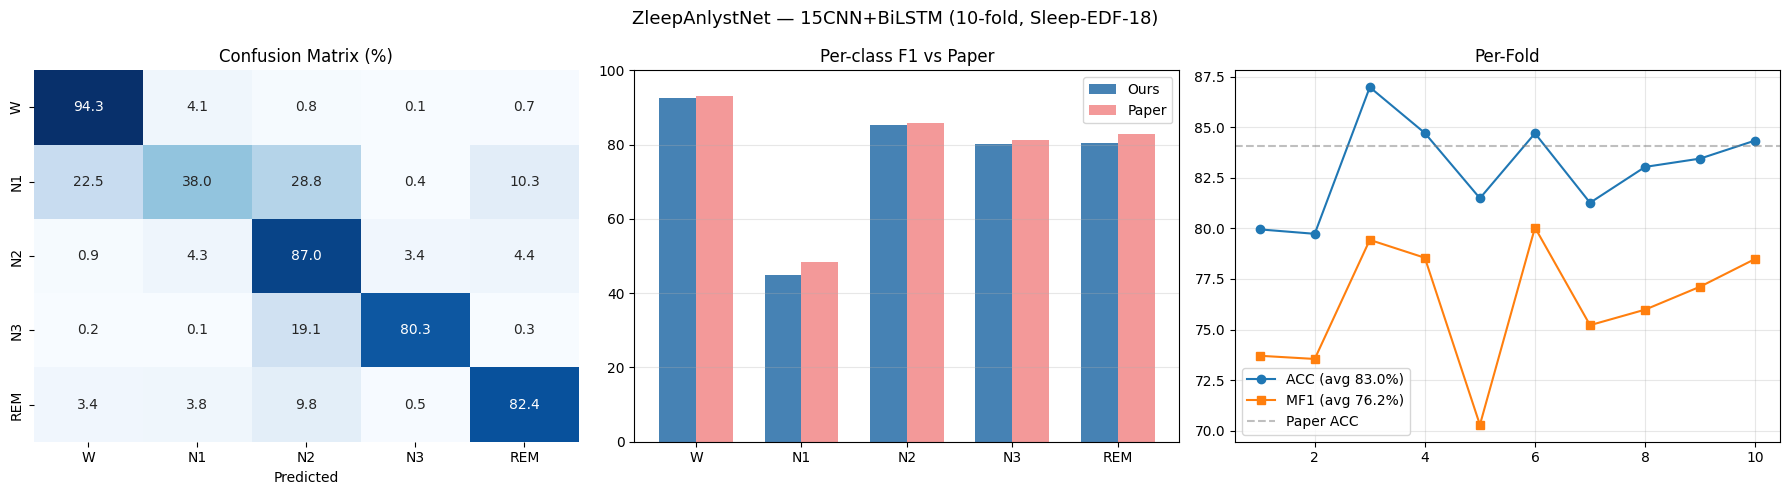

✓ Backup → /workspace/data/zleep_bilstm_output


In [15]:
# ════════════════════════════════════════════════════════════════
# CELL 14 — Lưu & Biểu đồ
# ════════════════════════════════════════════════════════════════

np.save(OUT_DIR / 'predictions.npy', all_preds)
np.save(OUT_DIR / 'ground_truth.npy', all_trues)
with open(OUT_DIR / 'results.json', 'w') as f:
    json.dump({'model': 'ZleepAnlystNet_15CNN_BiLSTM',
               'overall': overall, 'per_fold': fold_metrics}, f, indent=2)

DRIVE_OUT = DRIVE_FOLDER / 'zleep_bilstm_output'
DRIVE_OUT.mkdir(parents=True, exist_ok=True)
for fpath in OUT_DIR.iterdir():
    if fpath.is_file():
        shutil.copy(fpath, DRIVE_OUT / fpath.name)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ZleepAnlystNet — 15CNN+BiLSTM (10-fold, Sleep-EDF-18)', fontsize=13)

cm      = confusion_matrix(all_trues, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=SLEEP_STAGES, yticklabels=SLEEP_STAGES,
            ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix (%)'); axes[0].set_xlabel('Predicted')

x = np.arange(N_CLASSES); w = 0.35
ours  = [overall[f'f1_{s}']*100 for s in SLEEP_STAGES]
paper = [PAPER[f'f1_{s}']       for s in SLEEP_STAGES]
axes[1].bar(x-w/2, ours,  w, label='Ours',  color='steelblue')
axes[1].bar(x+w/2, paper, w, label='Paper', color='lightcoral', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(SLEEP_STAGES)
axes[1].set_ylim(0, 100); axes[1].set_title('Per-class F1 vs Paper')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

folds = [m['fold']    for m in fold_metrics]
f_acc = [m['acc']*100 for m in fold_metrics]
f_mf1 = [m['mf1']*100 for m in fold_metrics]
axes[2].plot(folds, f_acc, 'o-', label=f'ACC (avg {np.mean(f_acc):.1f}%)')
axes[2].plot(folds, f_mf1, 's-', label=f'MF1 (avg {np.mean(f_mf1):.1f}%)')
axes[2].axhline(84.09, color='gray', ls='--', alpha=0.5, label='Paper ACC')
axes[2].set_title('Per-Fold'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plot_path = OUT_DIR / 'results.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
shutil.copy(plot_path, DRIVE_OUT / 'results.png')
plt.show()
print(f'✓ Backup → {DRIVE_OUT}')
